# Jegadeesh–Titman Momentum — 12M — Winner Drift

One signal, one formation horizon and one maintenance method. The experiment contains nine cells: rebalance every 1, 3 or 6 months × target N=12, 24 or 50.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / 'src'))
from momentum_india.notebook_views import ResearchNotebook

research = ResearchNotebook('jt_academic', '12M', 'winner_drift')

## 1. Signal and portfolio rule

Raw price momentum ranks winners and losers. N denotes total names: N/2 winners long and N/2 losers short, normally ±1/N per name. The scheduled gross budgets are 50% each. This fixed-breadth, non-overlapping academic reference is not a replication of the paper's decile/cohort construction.

At scheduled rebalances, equal weight resets each leg's selected names. Winner drift retains relative position weights inside each leg, caps absolute weights at 2/N, and restores up to 50% gross per leg through scaling or equal residual allocation. Between scheduled dates both legs drift with prices. Borrowing is an academic 3%, 6% or 12% annual deduction on short notional; margin, recalls and stock-level borrow availability are not modeled.

## 2. Universe → ranking → actual portfolio

The example uses the latest monthly N=24 signal and exposes the ranking inputs and actual target weights.

Symbol,Formation price return,MDTV (INR)
NSE:CUPID-EQ,664.2%,"2,261,224,535.95"
NSE:ATHERENERG-EQ,259.7%,"2,745,338,022.88"
NSE:KMEW-EQ,196.2%,"175,654,741.20"
NSE:RPTECH-EQ,190.7%,"78,147,051.55"
NSE:THANGAMAYL-EQ,176.4%,"572,585,716.40"
NSE:SILVERTUC-EQ,157.3%,"65,229,764.81"
NSE:HFCL-EQ,156.6%,"3,688,024,397.99"
NSE:SANSERA-EQ,150.7%,"511,549,310.60"
NSE:NGLFINE-EQ,148.1%,"21,228,409.00"
NSE:KIRLOSENG-EQ,142.2%,"594,920,683.95"


Symbol,Leg,Actual weight,Current selection,Execution status,Formation price return,MDTV (INR)
NSE:CUPID-EQ,long,8.0%,True,selected,664.2%,"2,261,224,535.95"
NSE:ATHERENERG-EQ,long,4.4%,True,selected,259.7%,"2,745,338,022.88"
NSE:KMEW-EQ,long,4.4%,True,selected,196.2%,"175,654,741.20"
NSE:RPTECH-EQ,long,3.9%,True,selected,190.7%,"78,147,051.55"
NSE:THANGAMAYL-EQ,long,2.9%,True,selected,176.4%,"572,585,716.40"
NSE:SILVERTUC-EQ,long,4.0%,True,selected,157.3%,"65,229,764.81"
NSE:HFCL-EQ,long,4.0%,True,selected,156.6%,"3,688,024,397.99"
NSE:SANSERA-EQ,long,4.0%,True,selected,150.7%,"511,549,310.60"
NSE:NGLFINE-EQ,long,4.0%,True,selected,148.1%,"21,228,409.00"
NSE:KIRLOSENG-EQ,long,3.3%,True,selected,142.2%,"594,920,683.95"


Symbol,Formation start,Start adjusted close,Signal close date,End adjusted close,Formation price return
NSE:CUPID-EQ,2025-07-31,30.18,2026-07-31,230.62,664.2%


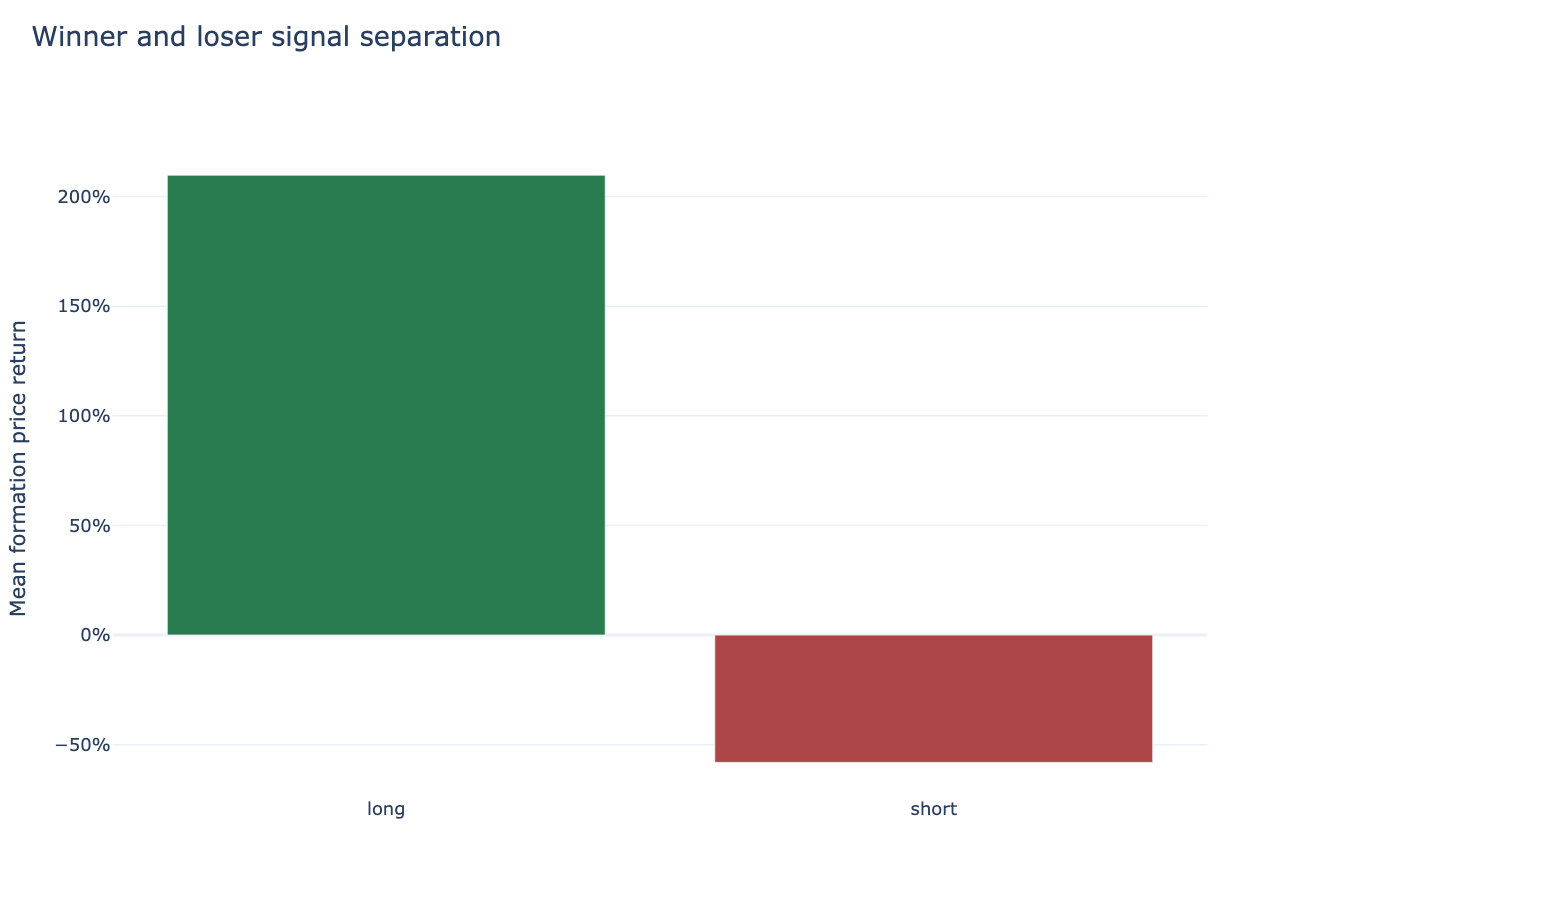

In [2]:
research.snapshot()

## 3. Return layers across all nine cells

Raw is before trading charges. After-cost gross/pre-tax deducts modeled trading charges. The long-only post-tax overlay additionally applies the annual equity-gains ledger. The academic reference instead compares raw and borrowing-adjusted layers.

In [3]:
research.layers_bridge()

Rebalance,First date,Last date,Sessions
1M,2007-05-03,2026-08-28,4771
3M,2007-07-02,2026-08-28,4729
6M,2007-07-02,2026-08-28,4729


Rebalance,N,Academic raw,Borrow 3%,Borrow 6%,Borrow 12%
1M,12,25.2%,22.2%,19.2%,12.8%
1M,24,23.7%,21.0%,18.3%,12.7%
1M,50,25.7%,23.2%,20.7%,15.6%
3M,12,29.1%,26.3%,23.5%,17.7%
3M,24,24.8%,22.3%,19.7%,14.3%
3M,50,24.7%,22.3%,20.0%,15.1%
6M,12,27.6%,25.5%,23.4%,19.1%
6M,24,25.8%,23.8%,21.7%,17.6%
6M,50,22.6%,20.7%,18.7%,14.8%


## 4. Risk-adjusted results

Sharpe uses daily excess returns relative to the liquid fund. VaR and expected shortfall are historical monthly 95% loss measures. Partial first/last months are included. Time below prior peak counts days awaiting a new all-time high—not losing days. The initial invested capital is included as the first peak.

In [4]:
research.risk_grid()

Rebalance,N,CAGR,Sharpe,Max drawdown,Monthly VaR 95%
1M,12,19.2%,0.555,-73.3%,13.2%
1M,24,18.3%,0.647,-63.7%,10.7%
1M,50,20.7%,0.964,-54.3%,7.5%
3M,12,23.5%,0.728,-57.0%,9.6%
3M,24,19.7%,0.694,-73.2%,8.8%
3M,50,20.0%,0.787,-75.7%,6.5%
6M,12,23.4%,0.791,-68.2%,8.2%
6M,24,21.7%,0.947,-59.4%,5.1%
6M,50,18.7%,1.010,-46.3%,3.9%


Rebalance,N,Monthly ES 95%,Time below prior peak,Longest underwater (sessions)
1M,12,21.9%,92.9%,1379
1M,24,16.9%,91.5%,1313
1M,50,13.3%,88.0%,839
3M,12,17.2%,90.0%,845
3M,24,16.4%,89.7%,1183
3M,50,14.1%,86.7%,847
6M,12,14.6%,90.3%,1531
6M,24,10.2%,87.3%,613
6M,50,8.9%,85.5%,627


### CAGR

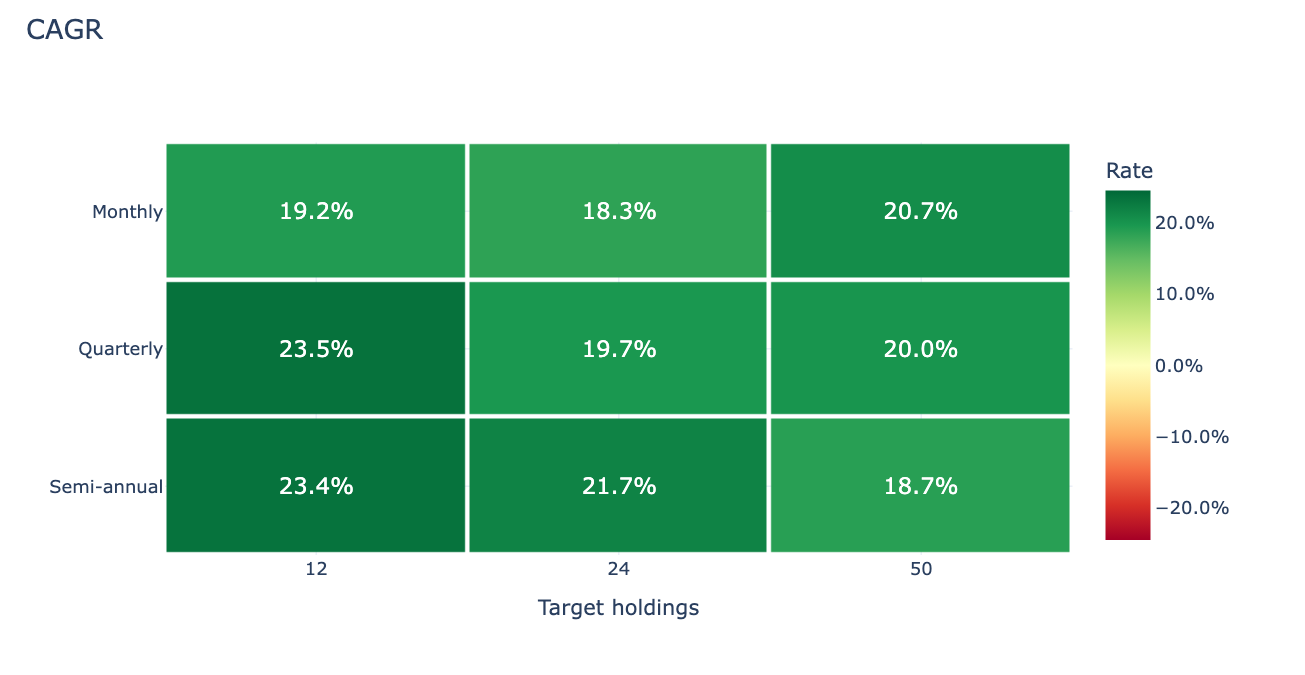

In [5]:
research.heatmap('cagr')

### Sharpe ratio

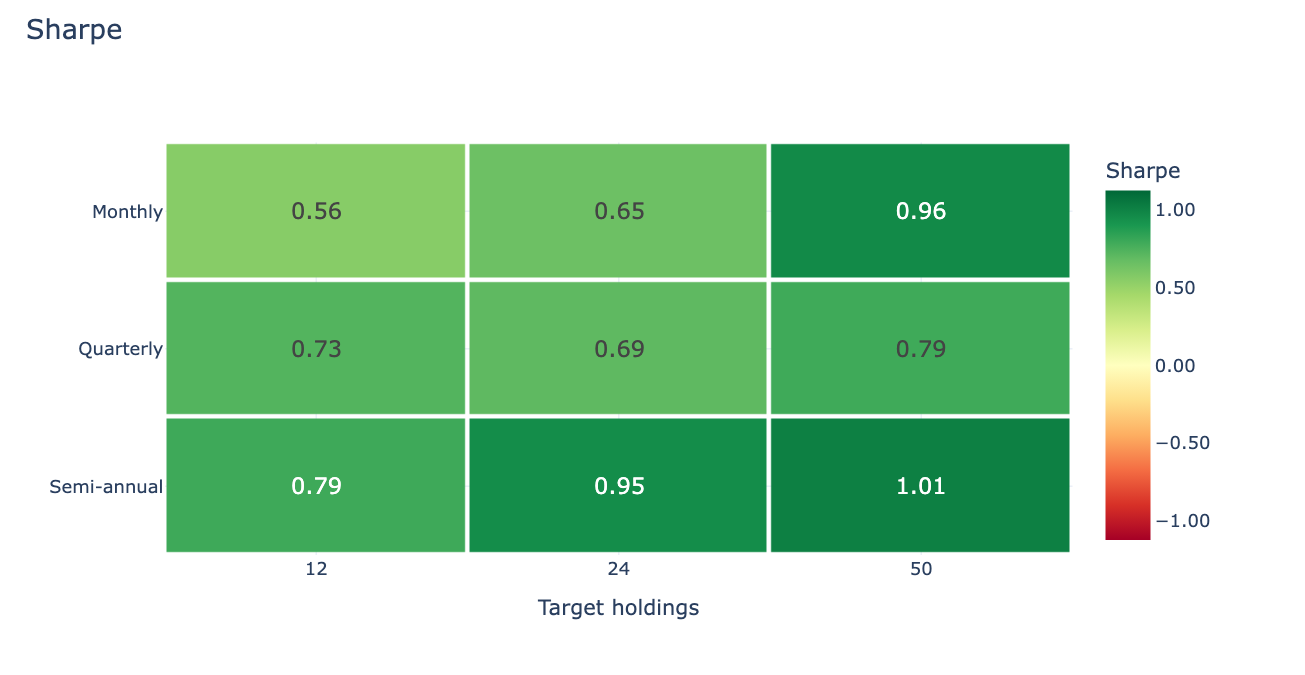

In [6]:
research.heatmap('sharpe')

### Maximum drawdown

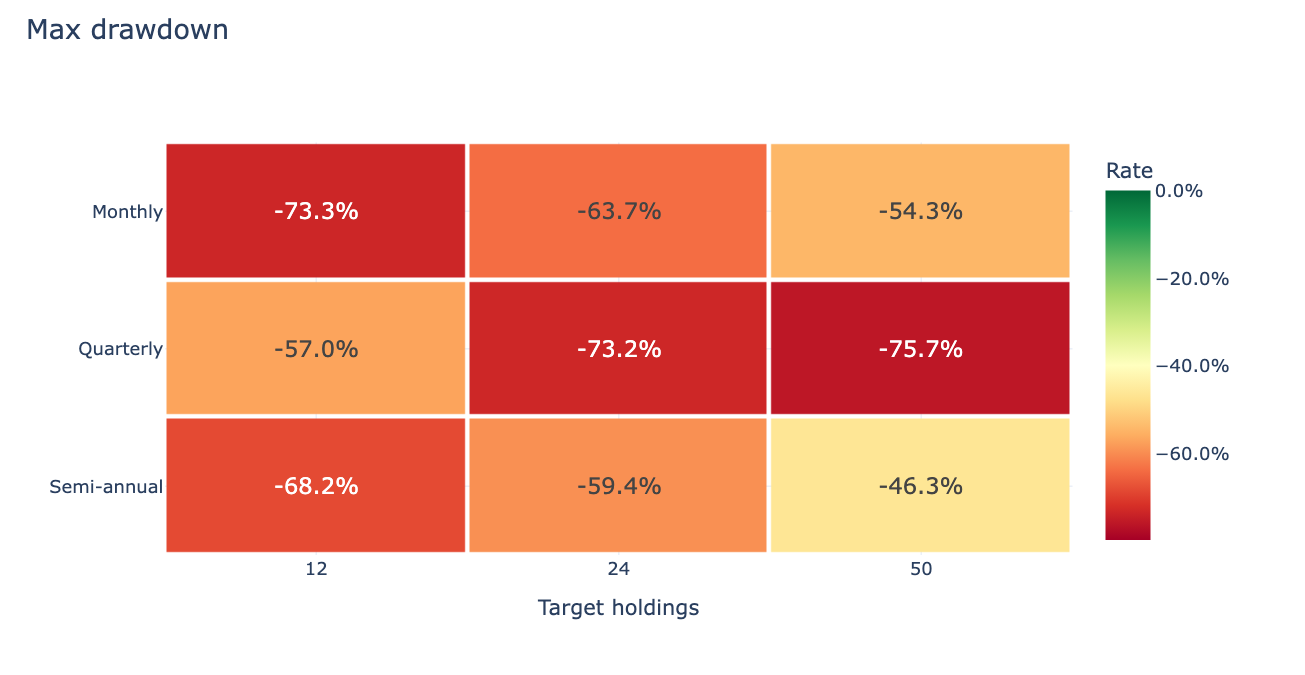

In [7]:
research.heatmap('maximum_drawdown')

### Monthly 95% VaR

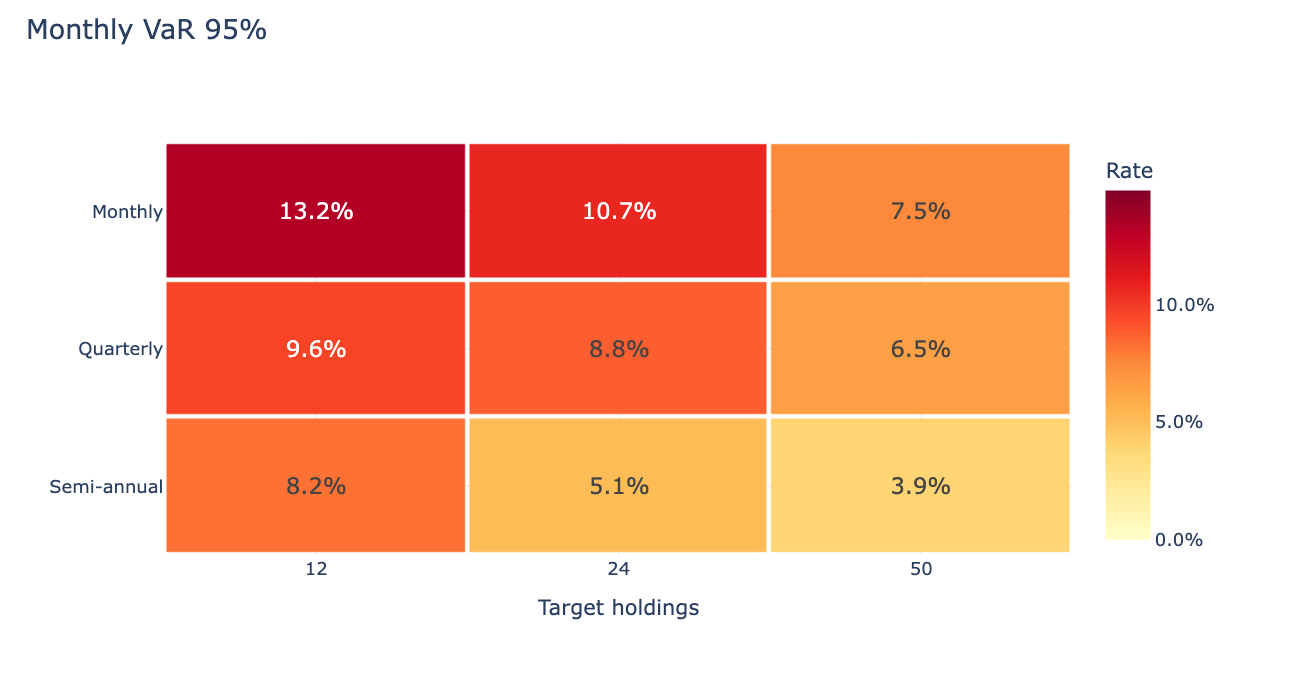

In [8]:
research.heatmap('monthly_var_95')

## 5. Equity paths and matched risks

Each chart fixes breadth and compares rebalance frequencies. Final-layer curves and the price benchmark start visible; other return layers remain in the selectable legend. Logarithmic axes make early and late periods comparable; the bottom range slider preserves the full history. Curves display weekly observations for readability, while every statistic uses the complete daily series.

### N=12

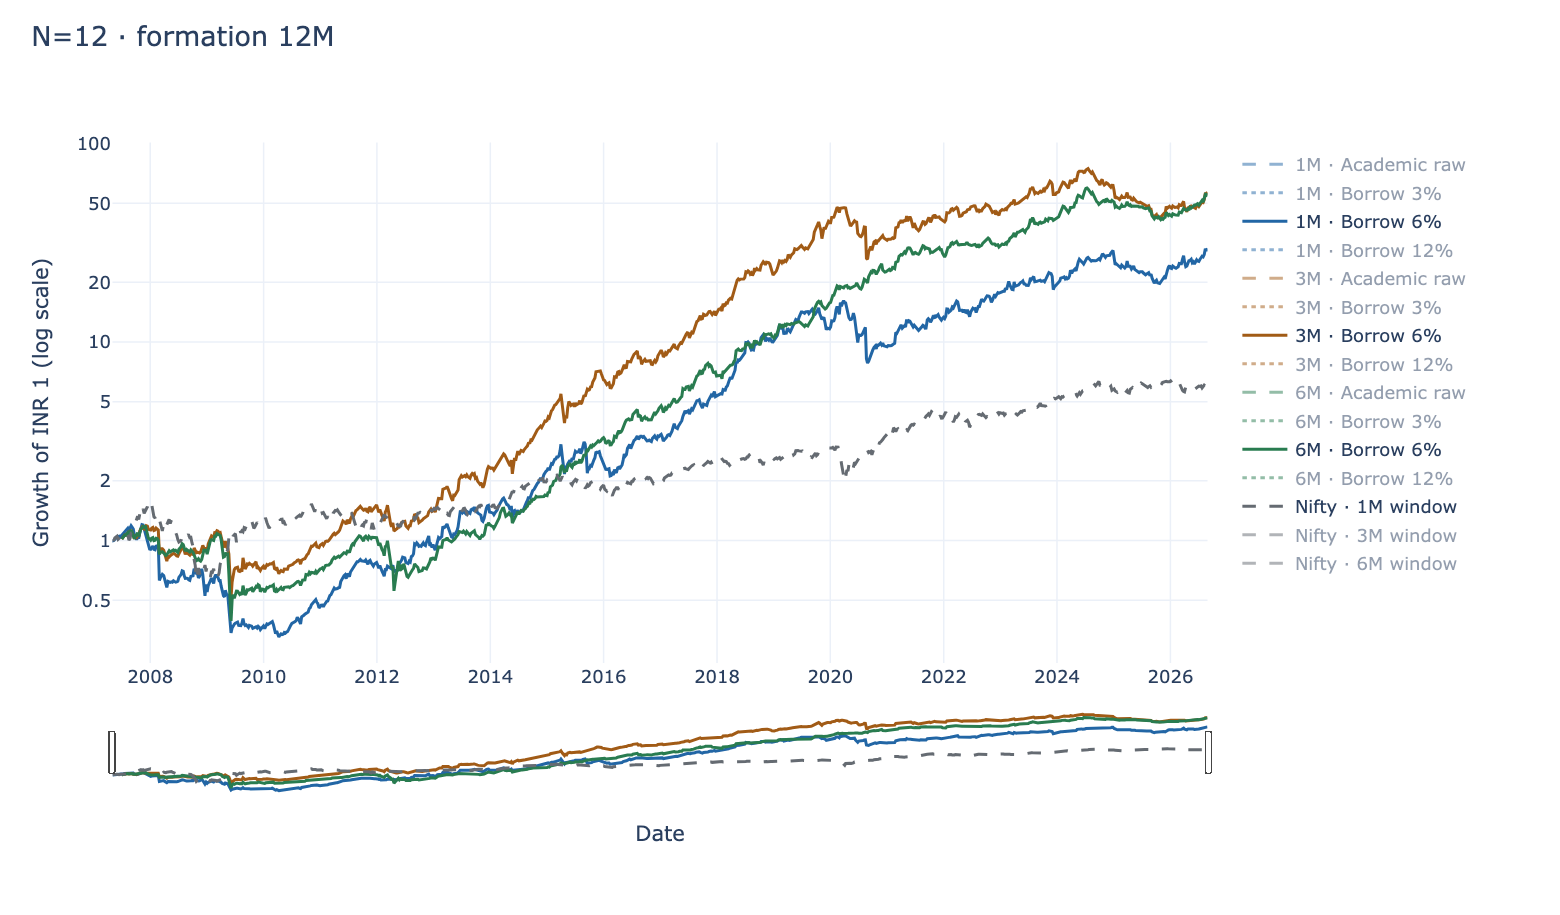

Rebalance,Return layer,CAGR,Sharpe,Max drawdown,Monthly VaR 95%
1M,Academic raw,25.2%,0.757,-69.7%,12.9%
1M,Borrow 3%,22.2%,0.658,-71.6%,13.0%
1M,Borrow 6%,19.2%,0.555,-73.3%,13.2%
1M,Borrow 12%,12.8%,0.337,-76.6%,13.6%
1M,Nifty 50 price,9.7%,0.219,-59.9%,6.9%
3M,Academic raw,29.1%,0.925,-53.9%,9.2%
3M,Borrow 3%,26.3%,0.828,-55.5%,9.4%
3M,Borrow 6%,23.5%,0.728,-57.0%,9.6%
3M,Borrow 12%,17.7%,0.518,-59.9%,10.1%
3M,Nifty 50 price,9.5%,0.209,-59.9%,7.0%


Rebalance,Return layer,Monthly ES 95%,Time below prior peak,Longest underwater (sessions)
1M,Academic raw,21.3%,90.9%,1196
1M,Borrow 3%,21.6%,92.2%,1309
1M,Borrow 6%,21.9%,92.9%,1379
1M,Borrow 12%,22.5%,94.6%,1692
3M,Academic raw,16.6%,88.4%,805
3M,Borrow 3%,16.9%,89.3%,836
3M,Borrow 6%,17.2%,90.0%,845
3M,Borrow 12%,17.8%,92.1%,910
6M,Academic raw,14.1%,88.8%,1309
6M,Borrow 3%,14.4%,89.7%,1366


In [9]:
research.equity(12)

### N=24

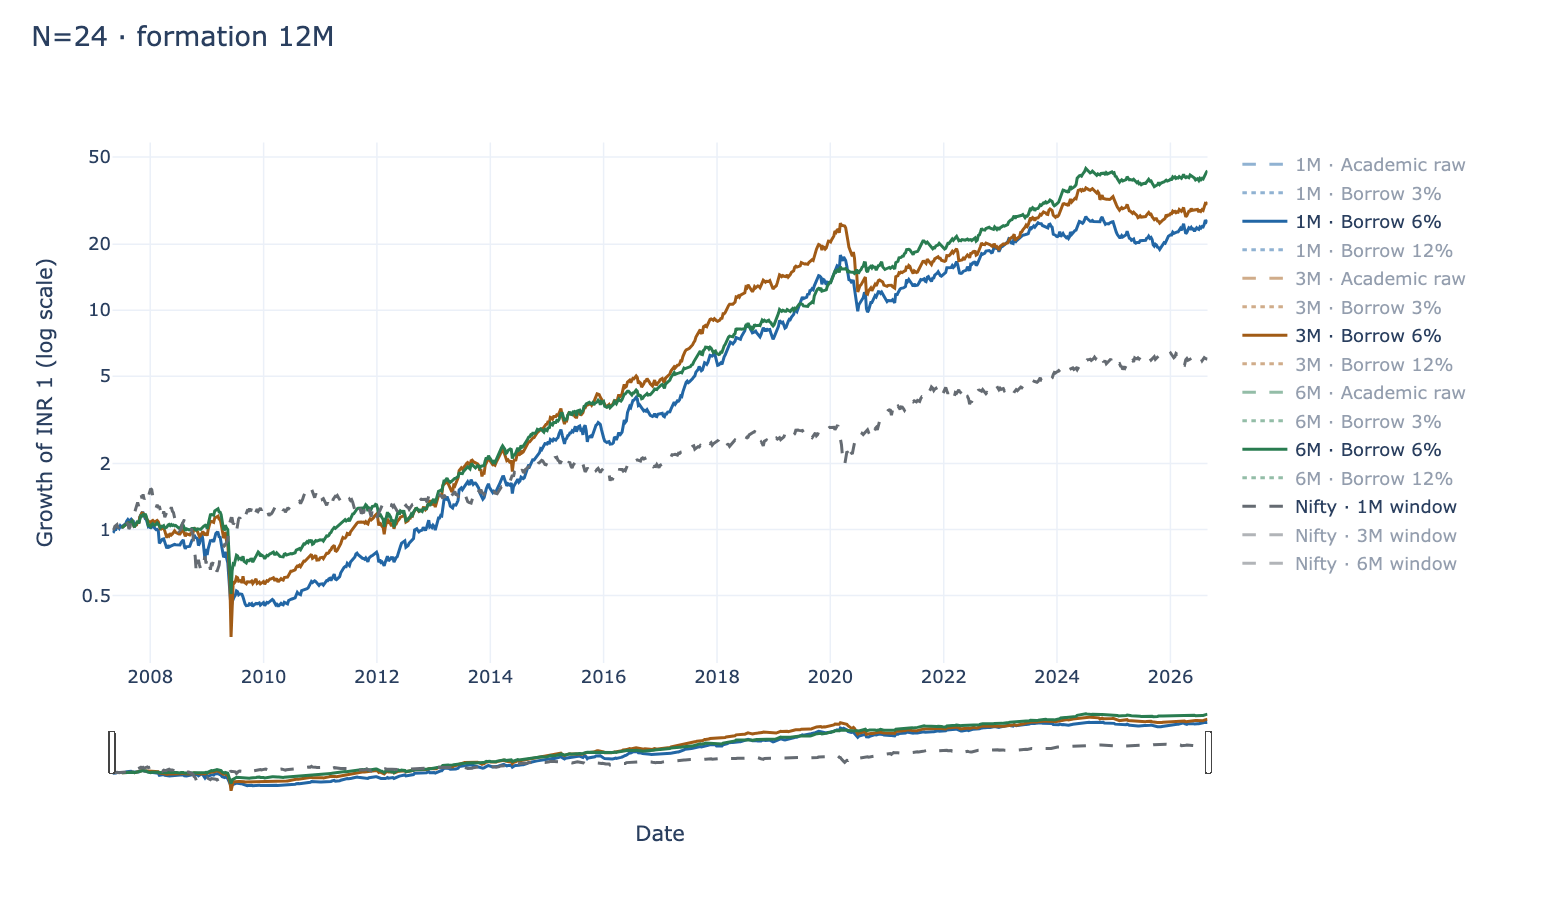

Rebalance,Return layer,CAGR,Sharpe,Max drawdown,Monthly VaR 95%
1M,Academic raw,23.7%,0.904,-61.3%,10.3%
1M,Borrow 3%,21.0%,0.777,-62.6%,10.5%
1M,Borrow 6%,18.3%,0.647,-63.7%,10.7%
1M,Borrow 12%,12.7%,0.374,-66.7%,11.1%
1M,Nifty 50 price,9.7%,0.219,-59.9%,6.9%
3M,Academic raw,24.8%,0.934,-71.2%,8.1%
3M,Borrow 3%,22.3%,0.815,-72.2%,8.5%
3M,Borrow 6%,19.7%,0.694,-73.2%,8.8%
3M,Borrow 12%,14.3%,0.442,-75.2%,9.4%
3M,Nifty 50 price,9.5%,0.209,-59.9%,7.0%


Rebalance,Return layer,Monthly ES 95%,Time below prior peak,Longest underwater (sessions)
1M,Academic raw,16.4%,89.3%,1189
1M,Borrow 3%,16.7%,90.3%,1247
1M,Borrow 6%,16.9%,91.5%,1313
1M,Borrow 12%,17.4%,93.5%,1391
3M,Academic raw,15.8%,87.4%,754
3M,Borrow 3%,16.1%,88.4%,983
3M,Borrow 6%,16.4%,89.7%,1183
3M,Borrow 12%,17.0%,92.1%,1307
6M,Academic raw,9.8%,85.2%,585
6M,Borrow 3%,10.0%,86.1%,599


In [10]:
research.equity(24)

### N=50

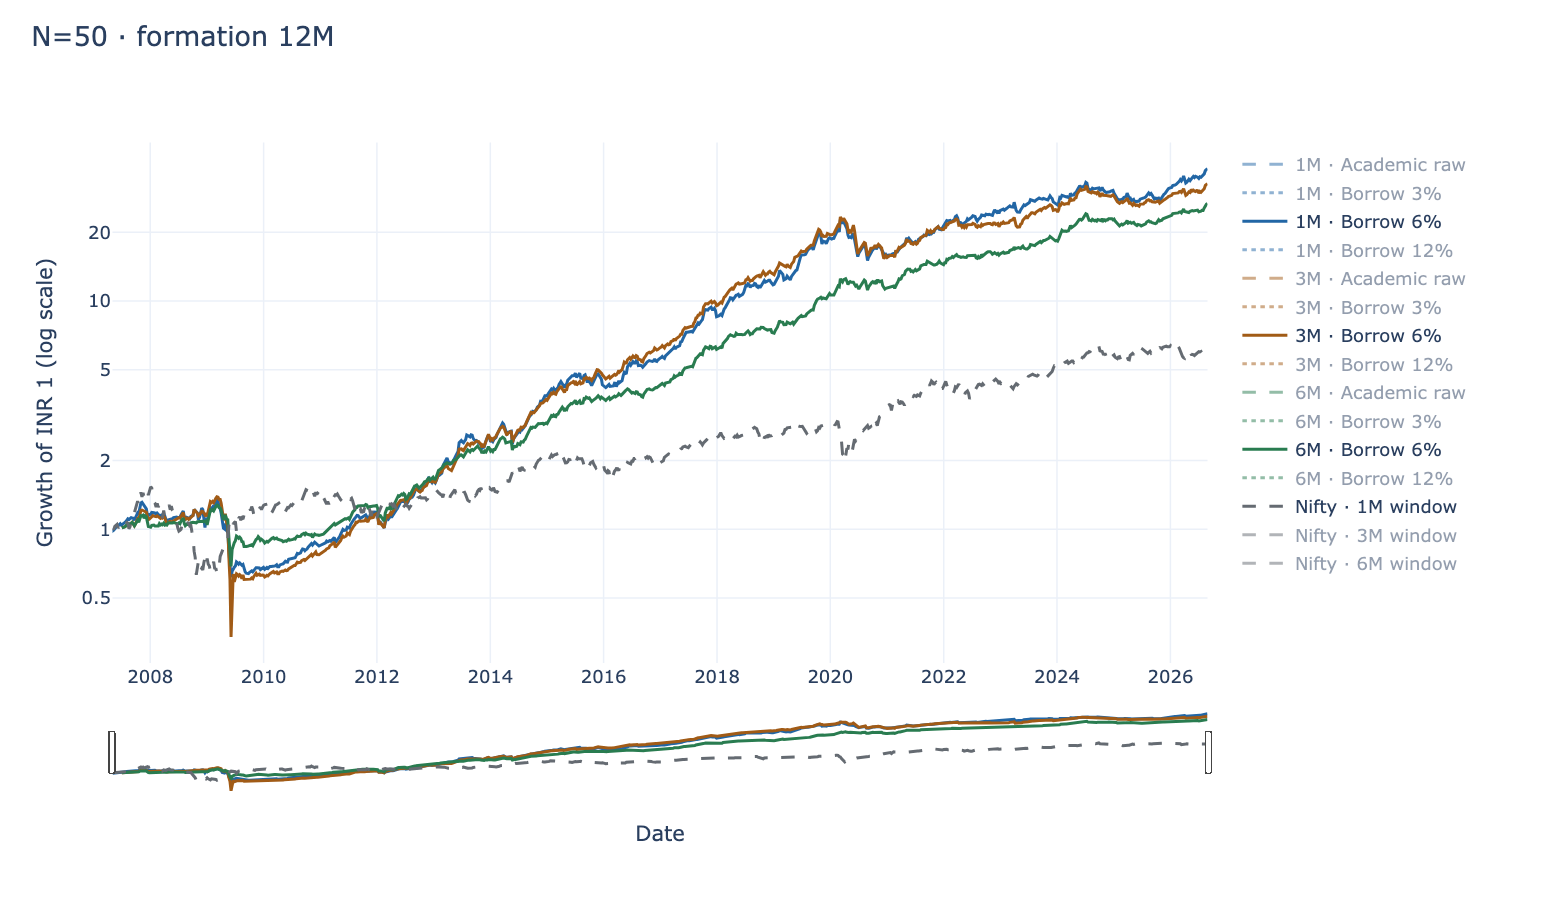

Rebalance,Return layer,CAGR,Sharpe,Max drawdown,Monthly VaR 95%
1M,Academic raw,25.7%,1.278,-53.7%,7.1%
1M,Borrow 3%,23.2%,1.122,-54.0%,7.3%
1M,Borrow 6%,20.7%,0.964,-54.3%,7.5%
1M,Borrow 12%,15.6%,0.638,-56.0%,7.9%
1M,Nifty 50 price,9.7%,0.219,-59.9%,6.9%
3M,Academic raw,24.7%,1.044,-74.8%,6.1%
3M,Borrow 3%,22.3%,0.916,-75.3%,6.3%
3M,Borrow 6%,20.0%,0.787,-75.7%,6.5%
3M,Borrow 12%,15.1%,0.523,-76.7%,6.9%
3M,Nifty 50 price,9.5%,0.209,-59.9%,7.0%


Rebalance,Return layer,Monthly ES 95%,Time below prior peak,Longest underwater (sessions)
1M,Academic raw,12.9%,84.5%,773
1M,Borrow 3%,13.1%,86.3%,790
1M,Borrow 6%,13.3%,88.0%,839
1M,Borrow 12%,13.8%,90.7%,1243
3M,Academic raw,13.6%,83.5%,772
3M,Borrow 3%,13.8%,84.9%,788
3M,Borrow 6%,14.1%,86.7%,847
3M,Borrow 12%,14.5%,89.6%,1026
6M,Academic raw,8.6%,83.1%,590
6M,Borrow 3%,8.8%,84.3%,603


In [11]:
research.equity(50)

## 6. Recovery burden

The longest underwater episode is shown by its peak, trough and recovery dates. Unrecovered episodes remain explicitly open.

In [12]:
research.recovery()

Series,Peak,Trough,Recovery,Sessions,Calendar days,Episode loss
1M,2007-11-06,2009-06-05,2013-03-01,1313,1941,-63.7%
3M,2007-11-14,2009-06-05,2012-08-31,1183,1751,-73.2%
6M,2009-03-09,2009-06-05,2011-08-30,613,901,-59.4%
Nifty · 1M,2008-01-08,2008-10-27,2014-03-06,1520,2248,-59.9%
Nifty · 3M,2008-01-08,2008-10-27,2014-03-06,1520,2248,-59.9%
Nifty · 6M,2008-01-08,2008-10-27,2014-03-06,1520,2248,-59.9%


## 7. Portfolio behavior

Scheduled turnover is (buy value + sell value)/(2 × pre-trade equity). Retention compares successive scheduled target name sets. Cash and total charges include the intervening daily path.

In [13]:
research.behavior()

Rebalance,N,Mean long exposure,Mean short exposure,Borrow fees (INR)
1M,12,60.8%,88.9%,"98,695,045.43"
1M,24,58.9%,79.1%,"85,546,794.49"
1M,50,60.3%,70.9%,"100,269,732.46"
3M,12,58.2%,79.7%,"232,011,731.03"
3M,24,59.9%,74.4%,"99,940,907.34"
3M,50,61.1%,66.9%,"93,936,308.87"
6M,12,59.7%,58.8%,"113,883,644.44"
6M,24,56.3%,57.7%,"82,948,447.59"
6M,50,57.2%,56.1%,"55,267,184.15"


## 8. Market-state attribution

This is an observation, not an extra strategy filter. Prior-close Nifty 50 versus SMA(200) defines up/down; 63-session volatility versus its expanding historical median defines high/low volatility. The representative monthly N=24 path is shown with shaded states.

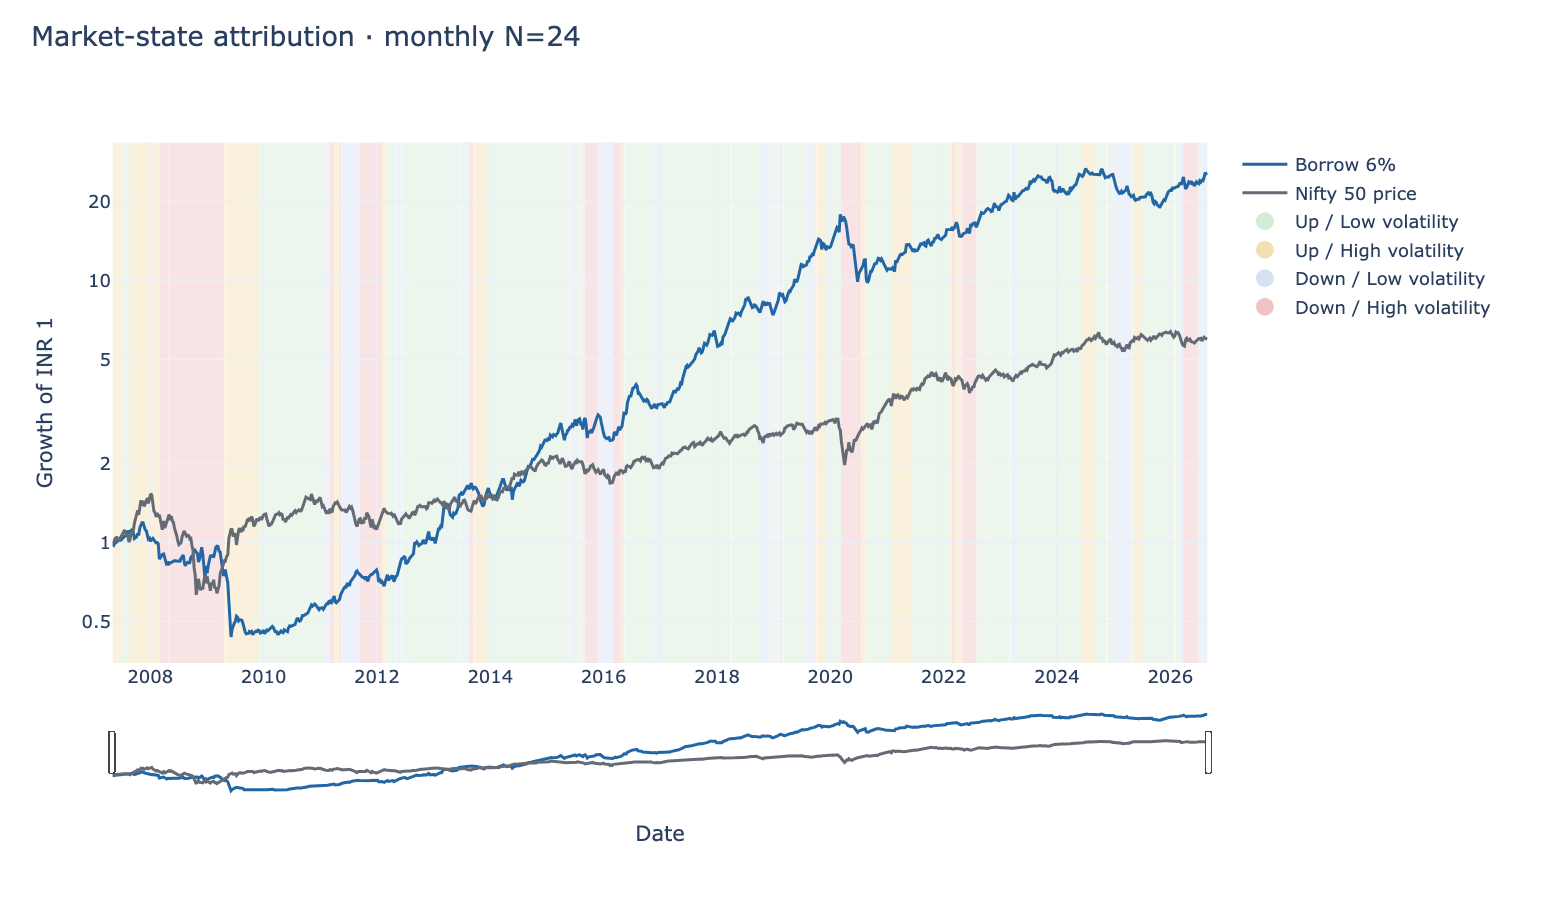

Market state,Sessions,Mean daily return,Daily volatility,Positive days
Down / High volatility,748,-0.04%,1.36%,51.74%
Down / Low volatility,609,0.15%,1.16%,56.81%
Up / High volatility,720,-0.07%,1.38%,50.83%
Up / Low volatility,2694,0.13%,1.00%,56.38%


In [14]:
research.regimes()

## 9. Complete portfolio and trade evidence

Risk metrics are included in the repository. Complete portfolio and trade CSVs belong to the local full-data research run.

In [15]:
research.portfolio_exports()

Rebalance,N,First rebalance,Last rebalance,Rebalance dates,Holding rows
1M,12,2007-05-03,2026-08-03,232,5619
1M,24,2007-05-03,2026-08-03,232,10026
1M,50,2007-05-03,2026-08-03,232,19804
3M,12,2007-07-02,2026-07-01,77,1744
3M,24,2007-07-02,2026-07-01,77,3263
3M,50,2007-07-02,2026-07-01,77,6333
6M,12,2007-07-02,2026-07-01,39,810
6M,24,2007-07-02,2026-07-01,39,1591
6M,50,2007-07-02,2026-07-01,39,3027


## Findings

In [16]:
research.conclusion()